# Malaysia YouTube Sentiment Analysis – Final Model Training and Evaluation

This notebook trains and evaluates sentiment classification models using the final translated-English, cleaned, and balanced YouTube comment dataset.

The task is a three-class sentiment classification problem:
- negative
- neutral
- positive

The final model is selected based on macro F1-score because all three sentiment classes are equally important.

In [2]:
from pathlib import Path
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

**1. Dataset Quality Check**


In [4]:
PROJECT_ROOT = Path(r"C:\Users\FadSaif\Documents\malaysia_sentiment_project_2")

DATA_FILE = PROJECT_ROOT / "Data" / "processed" / "final_youtube_sentiment_translated_en_cleaned_v2_balanced.csv"

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{DATA_FILE}\n\n"
        "Run the cleaning/relabel cell first. It must create final_youtube_sentiment_translated_en_cleaned_v1.csv."
    )

df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")

TEXT_COLUMN = "translated_text_en"
LABEL_COLUMN = "sentiment"

required_columns = [TEXT_COLUMN, LABEL_COLUMN]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df.copy()

df[TEXT_COLUMN] = df[TEXT_COLUMN].fillna("").astype(str).str.strip()
df[LABEL_COLUMN] = df[LABEL_COLUMN].fillna("").astype(str).str.strip().str.lower()

valid_labels = ["negative", "neutral", "positive"]

df = df[df[LABEL_COLUMN].isin(valid_labels)]
df = df[df[TEXT_COLUMN] != ""]

df = df.drop_duplicates(subset=[TEXT_COLUMN, LABEL_COLUMN]).reset_index(drop=True)

print("Dataset file:", DATA_FILE)
print("Final training dataset shape:", df.shape)
print("\nLabel distribution:")
print(df[LABEL_COLUMN].value_counts())

df[[TEXT_COLUMN, LABEL_COLUMN]].head()

Dataset file: C:\Users\FadSaif\Documents\malaysia_sentiment_project_2\Data\processed\final_youtube_sentiment_translated_en_cleaned_v2_balanced.csv
Final training dataset shape: (450, 77)

Label distribution:
sentiment
positive    150
negative    150
neutral     150
Name: count, dtype: int64


,translated_text_en,sentiment
0,PMX who perseveres in carrying out his duties ...,positive
1,"it's better to have a physical license, it's e...",positive
2,"In term of driving, you can said comfortable ,...",negative
3,You don't have to try to taste the people.. I ...,negative
4,"That's right, just abolish the JPJ because he ...",positive


**2. Label Distribution Chart**

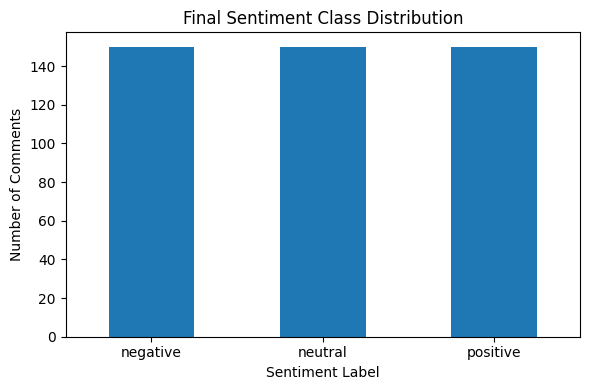

In [6]:
label_counts = df[LABEL_COLUMN].value_counts().reindex(valid_labels)

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Final Sentiment Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**3. Train-Test Split**

In [8]:
X = df[TEXT_COLUMN]
y = df[LABEL_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training size:", len(X_train))
print("Testing size :", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training size: 360
Testing size : 90

Training distribution:
sentiment
neutral     120
positive    120
negative    120
Name: count, dtype: int64

Testing distribution:
sentiment
positive    30
negative    30
neutral     30
Name: count, dtype: int64


**4. Evaluation Helper**

In [10]:
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    result = {
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted,
    }

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print("Accuracy :", round(accuracy, 4))
    print("Macro F1 :", round(f1_macro, 4))
    print()
    print(classification_report(y_true, y_pred, labels=valid_labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=valid_labels)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(range(len(valid_labels)), valid_labels, rotation=45)
    plt.yticks(range(len(valid_labels)), valid_labels)

    for i in range(len(valid_labels)):
        for j in range(len(valid_labels)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

    return result

**5. Model 1: Logistic Regression baseline**

TF-IDF + Logistic Regression
Accuracy : 0.6778
Macro F1 : 0.6791

              precision    recall  f1-score   support

    negative       0.61      0.73      0.67        30
     neutral       0.64      0.60      0.62        30
    positive       0.81      0.70      0.75        30

    accuracy                           0.68        90
   macro avg       0.69      0.68      0.68        90
weighted avg       0.69      0.68      0.68        90



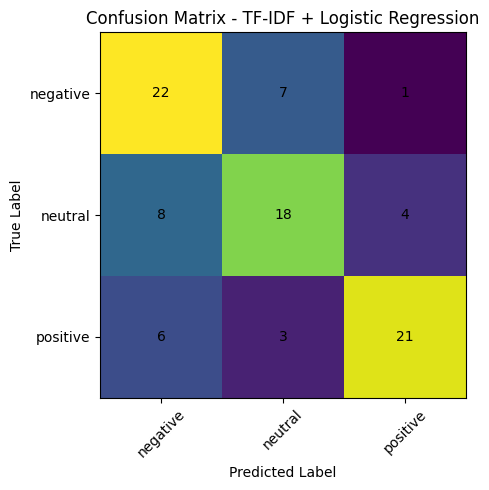

In [12]:
logreg_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

logreg_model.fit(X_train, y_train)

logreg_predictions = logreg_model.predict(X_test)

logreg_result = evaluate_model(
    "TF-IDF + Logistic Regression",
    y_test,
    logreg_predictions,
)

**6. Model 2: Linear SVM**

TF-IDF + Linear SVM
Accuracy : 0.6667
Macro F1 : 0.6648

              precision    recall  f1-score   support

    negative       0.62      0.70      0.66        30
     neutral       0.62      0.53      0.57        30
    positive       0.77      0.77      0.77        30

    accuracy                           0.67        90
   macro avg       0.67      0.67      0.66        90
weighted avg       0.67      0.67      0.66        90



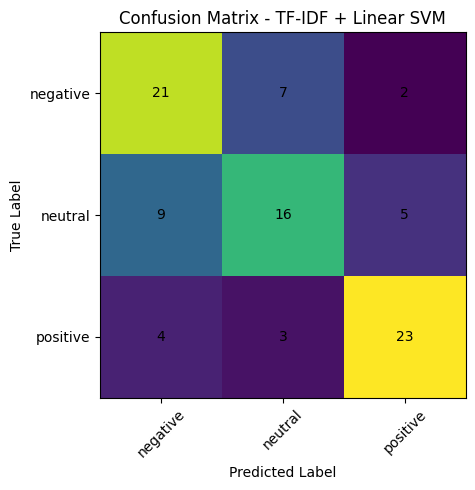

In [14]:
svm_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

svm_result = evaluate_model(
    "TF-IDF + Linear SVM",
    y_test,
    svm_predictions,
)

**7.1 Word + Character TF-IDF Logistic Regression**

Word + Char TF-IDF + Logistic Regression
Accuracy : 0.7333
Macro F1 : 0.7333

              precision    recall  f1-score   support

    negative       0.71      0.80      0.75        30
     neutral       0.69      0.67      0.68        30
    positive       0.81      0.73      0.77        30

    accuracy                           0.73        90
   macro avg       0.74      0.73      0.73        90
weighted avg       0.74      0.73      0.73        90



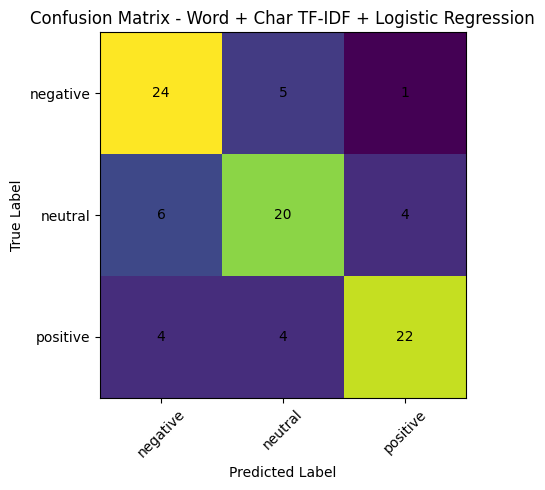

In [16]:
word_char_logreg_model = Pipeline(
    steps=[
        (
            "features",
            FeatureUnion(
                [
                    (
                        "word_tfidf",
                        TfidfVectorizer(
                            analyzer="word",
                            lowercase=True,
                            ngram_range=(1, 2),
                            min_df=2,
                            max_df=0.95,
                            sublinear_tf=True,
                        ),
                    ),
                    (
                        "char_tfidf",
                        TfidfVectorizer(
                            analyzer="char_wb",
                            lowercase=True,
                            ngram_range=(3, 5),
                            min_df=2,
                            max_df=0.95,
                            sublinear_tf=True,
                        ),
                    ),
                ]
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

word_char_logreg_model.fit(X_train, y_train)

word_char_logreg_predictions = word_char_logreg_model.predict(X_test)

word_char_logreg_result = evaluate_model(
    "Word + Char TF-IDF + Logistic Regression",
    y_test,
    word_char_logreg_predictions,
)

**7.2 Word + Character TF-IDF Linear SVM**

Word + Char TF-IDF + Linear SVM
Accuracy : 0.7111
Macro F1 : 0.7091

              precision    recall  f1-score   support

    negative       0.71      0.80      0.75        30
     neutral       0.67      0.60      0.63        30
    positive       0.76      0.73      0.75        30

    accuracy                           0.71        90
   macro avg       0.71      0.71      0.71        90
weighted avg       0.71      0.71      0.71        90



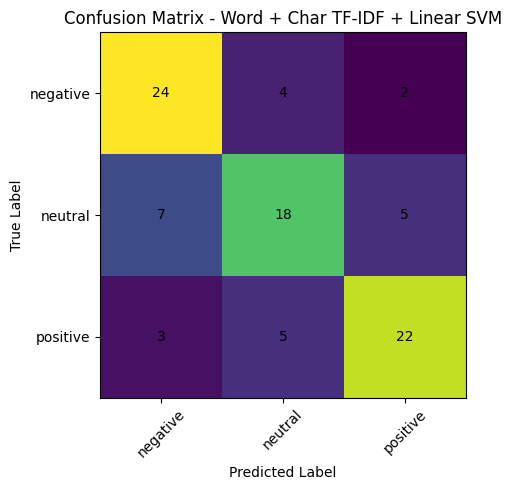

In [18]:
word_char_svm_model = Pipeline(
    steps=[
        (
            "features",
            FeatureUnion(
                [
                    (
                        "word_tfidf",
                        TfidfVectorizer(
                            analyzer="word",
                            lowercase=True,
                            ngram_range=(1, 2),
                            min_df=2,
                            max_df=0.95,
                            sublinear_tf=True,
                        ),
                    ),
                    (
                        "char_tfidf",
                        TfidfVectorizer(
                            analyzer="char_wb",
                            lowercase=True,
                            ngram_range=(3, 5),
                            min_df=2,
                            max_df=0.95,
                            sublinear_tf=True,
                        ),
                    ),
                ]
            ),
        ),
        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                random_state=42,
                max_iter=5000,
            ),
        ),
    ]
)

word_char_svm_model.fit(X_train, y_train)

word_char_svm_predictions = word_char_svm_model.predict(X_test)

word_char_svm_result = evaluate_model(
    "Word + Char TF-IDF + Linear SVM",
    y_test,
    word_char_svm_predictions,
)

 **8. Tuned English Classical Models**

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Logistic Regression parameters:
{'clf__C': 1, 'tfidf__max_df': 0.85, 'tfidf__max_features': 10000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best CV macro F1: 0.6248886575019885
Tuned English TF-IDF + Logistic Regression
Accuracy : 0.7222
Macro F1 : 0.7176

              precision    recall  f1-score   support

    negative       0.63      0.90      0.74        30
     neutral       0.76      0.53      0.63        30
    positive       0.85      0.73      0.79        30

    accuracy                           0.72        90
   macro avg       0.75      0.72      0.72        90
weighted avg       0.75      0.72      0.72        90



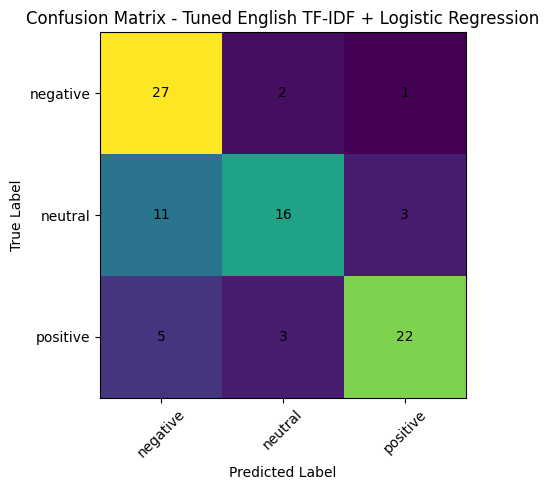

In [21]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_params = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.85, 0.95, 1.0],
    "tfidf__max_features": [3000, 5000, 10000],
    "clf__C": [0.5, 1, 2, 5]
}

logreg_grid = GridSearchCV(
    logreg_pipeline,
    logreg_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

logreg_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(logreg_grid.best_params_)
print("Best CV macro F1:", logreg_grid.best_score_)

tuned_logreg_predictions = logreg_grid.best_estimator_.predict(X_test)

tuned_logreg_result = evaluate_model(
    "Tuned English TF-IDF + Logistic Regression",
    y_test,
    tuned_logreg_predictions,
)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best Linear SVM parameters:
{'clf__C': 0.25, 'tfidf__analyzer': 'word', 'tfidf__max_df': 0.85, 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best CV macro F1: 0.6291183315217552
Tuned English TF-IDF + Linear SVM
Accuracy : 0.7222
Macro F1 : 0.7257

              precision    recall  f1-score   support

    negative       0.62      0.80      0.70        30
     neutral       0.70      0.63      0.67        30
    positive       0.92      0.73      0.81        30

    accuracy                           0.72        90
   macro avg       0.75      0.72      0.73        90
weighted avg       0.75      0.72      0.73        90



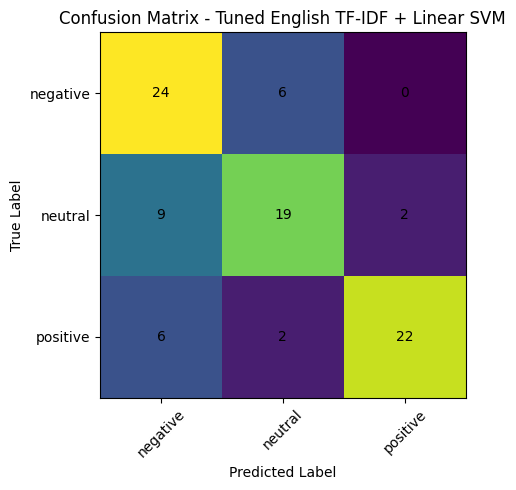

In [22]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

svm_params = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__analyzer": ["word"],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.85, 0.95, 1.0],
    "tfidf__max_features": [3000, 5000, 10000],
    "clf__C": [0.25, 0.5, 1, 2, 5]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print("Best Linear SVM parameters:")
print(svm_grid.best_params_)
print("Best CV macro F1:", svm_grid.best_score_)

tuned_svm_predictions = svm_grid.best_estimator_.predict(X_test)

tuned_svm_result = evaluate_model(
    "Tuned English TF-IDF + Linear SVM",
    y_test,
    tuned_svm_predictions,
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Word + Character SVM parameters:
{'clf__C': 0.5}
Best CV macro F1: 0.6142177842761064
Tuned English Word + Character TF-IDF + Linear SVM
Accuracy : 0.7444
Macro F1 : 0.7407

              precision    recall  f1-score   support

    negative       0.76      0.83      0.79        30
     neutral       0.75      0.60      0.67        30
    positive       0.73      0.80      0.76        30

    accuracy                           0.74        90
   macro avg       0.74      0.74      0.74        90
weighted avg       0.74      0.74      0.74        90



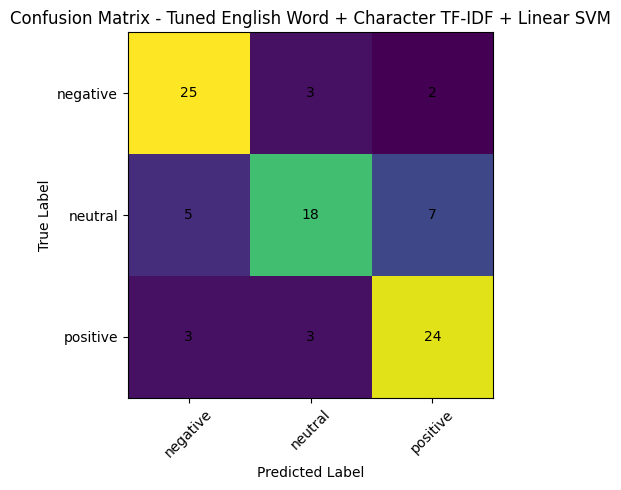

In [23]:
word_char_svm_pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=7000,
            min_df=1,
            max_df=0.95,
            sublinear_tf=True,
            lowercase=True,
            strip_accents="unicode"
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=5000,
            min_df=1,
            sublinear_tf=True,
            lowercase=True
        ))
    ])),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

word_char_svm_params = {
    "clf__C": [0.25, 0.5, 1, 2, 5]
}

word_char_svm_grid = GridSearchCV(
    word_char_svm_pipeline,
    word_char_svm_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

word_char_svm_grid.fit(X_train, y_train)

print("Best Word + Character SVM parameters:")
print(word_char_svm_grid.best_params_)
print("Best CV macro F1:", word_char_svm_grid.best_score_)

tuned_word_char_svm_predictions = word_char_svm_grid.best_estimator_.predict(X_test)

tuned_word_char_svm_result = evaluate_model(
    "Tuned English Word + Character TF-IDF + Linear SVM",
    y_test,
    tuned_word_char_svm_predictions,
)

In [24]:
tuned_results = pd.DataFrame([
    tuned_logreg_result,
    tuned_svm_result,
    tuned_word_char_svm_result
]).sort_values(by="macro_f1", ascending=False)

tuned_results

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
2,Tuned English Word + Character TF-IDF + Linear...,0.744444,0.744949,0.744444,0.740741,0.744949,0.744444,0.740741
1,Tuned English TF-IDF + Linear SVM,0.722222,0.745252,0.722222,0.725711,0.745252,0.722222,0.725711
0,Tuned English TF-IDF + Logistic Regression,0.722222,0.745322,0.722222,0.717630,0.745322,0.722222,0.717630


**9. Fine-Tuned DistilBERT English**

In [26]:
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
label_encoder = LabelEncoder()
label_encoder.fit(["negative", "neutral", "positive"])

train_df = pd.DataFrame({
    "text": X_train.reset_index(drop=True),
    "label": label_encoder.transform(y_train.reset_index(drop=True))
})

test_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": label_encoder.transform(y_test.reset_index(drop=True))
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize_batch, batched=True)
test_dataset = test_dataset.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={
        0: "negative",
        1: "neutral",
        2: "positive"
    },
    label2id={
        "negative": 0,
        "neutral": 1,
        "positive": 2
    }
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

training_args = TrainingArguments(
    output_dir=str(MODELS_DIR / "distilbert_translated_english"),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=20,
    save_total_limit=2,
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

fine_tuned_predictions = trainer.predict(test_dataset)
fine_tuned_pred_ids = np.argmax(fine_tuned_predictions.predictions, axis=-1)

fine_tuned_pred_labels = label_encoder.inverse_transform(fine_tuned_pred_ids)
fine_tuned_true_labels = label_encoder.inverse_transform(test_df["label"])

fine_tuned_accuracy = accuracy_score(fine_tuned_true_labels, fine_tuned_pred_labels)
fine_tuned_precision, fine_tuned_recall, fine_tuned_f1, _ = precision_recall_fscore_support(
    fine_tuned_true_labels,
    fine_tuned_pred_labels,
    average="macro",
    zero_division=0
)

fine_tuned_result = {
    "model": "Fine-Tuned DistilBERT English",
    "accuracy": fine_tuned_accuracy,
    "macro_precision": fine_tuned_precision,
    "macro_recall": fine_tuned_recall,
    "macro_f1": fine_tuned_f1,
    "weighted_precision": precision_recall_fscore_support(
        fine_tuned_true_labels,
        fine_tuned_pred_labels,
        average="weighted",
        zero_division=0
    )[0],
    "weighted_recall": precision_recall_fscore_support(
        fine_tuned_true_labels,
        fine_tuned_pred_labels,
        average="weighted",
        zero_division=0
    )[1],
    "weighted_f1": precision_recall_fscore_support(
        fine_tuned_true_labels,
        fine_tuned_pred_labels,
        average="weighted",
        zero_division=0
    )[2],
}

print("Fine-Tuned DistilBERT English")
print("Accuracy:", round(fine_tuned_accuracy, 4))
print("Macro F1:", round(fine_tuned_f1, 4))
print(classification_report(fine_tuned_true_labels, fine_tuned_pred_labels, zero_division=0))

Map:   0%|          | 0/360 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1.070243,1.069470,0.444444,0.462248,0.444444,0.443504
2,0.927300,0.991470,0.477778,0.473529,0.477778,0.468485
3,0.742779,0.969387,0.511111,0.510012,0.511111,0.494389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-Tuned DistilBERT English
Accuracy: 0.5111
Macro F1: 0.4944
              precision    recall  f1-score   support

    negative       0.54      0.63      0.58        30
     neutral       0.50      0.27      0.35        30
    positive       0.49      0.63      0.55        30

    accuracy                           0.51        90
   macro avg       0.51      0.51      0.49        90
weighted avg       0.51      0.51      0.49        90



In [27]:
**9.1 Error Analysis for the Best Classical Model**

SyntaxError: invalid syntax (1969546393.py, line 1)

In [ ]:
error_analysis_model = word_char_svm_grid.best_estimator_
error_analysis_predictions = error_analysis_model.predict(X_test)

error_df = pd.DataFrame({
    "translated_text_en": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "predicted_label": error_analysis_predictions
})

error_df = error_df[error_df["true_label"] != error_df["predicted_label"]]

print("Error analysis model: Tuned English Word + Character TF-IDF + Linear SVM")
print("Number of errors:", len(error_df))

error_df.head(30)

**10. Save Results and Best Model**

In [ ]:
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

final_results = pd.DataFrame([
    logreg_result,
    svm_result,
    word_char_logreg_result,
    word_char_svm_result,
    tuned_logreg_result,
    tuned_svm_result,
    tuned_word_char_svm_result,
    fine_tuned_result,
])

final_results = final_results.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

display(final_results)

RESULTS_FILE = RESULTS_DIR / "model_comparison_results_translated_en.csv"

final_results.to_csv(
    RESULTS_FILE,
    index=False,
    encoding="utf-8-sig",
)

metadata = {
    "dataset": str(DATA_FILE),
    "text_column": TEXT_COLUMN,
    "label_column": LABEL_COLUMN,
    "experiment_type": "English-translated dataset evaluation",
    "train_size": len(X_train),
    "test_size": len(X_test),
    "random_state": 42,
    "models_compared": final_results["model"].tolist(),
    "best_model_by_macro_f1": final_results.iloc[0]["model"],
    "best_macro_f1": float(final_results.iloc[0]["macro_f1"]),
    "best_accuracy": float(final_results.iloc[0]["accuracy"]),
}

METADATA_FILE = RESULTS_DIR / "translated_en_experiment_metadata.json"

with open(METADATA_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Saved translated-English model comparison results to:")
print(RESULTS_FILE)

print("\nSaved translated-English experiment metadata to:")
print(METADATA_FILE)

print("\nBest model by macro F1-score:")
print(final_results.iloc[0])

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(final_results["model"], final_results["macro_f1"])
plt.title("Translated-English Model Comparison by Macro F1-Score")
plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = final_results.iloc[0]["model"]

model_objects = {
    "TF-IDF + Logistic Regression": logreg_model,
    "TF-IDF + Linear SVM": svm_model,
    "Word + Char TF-IDF + Logistic Regression": word_char_logreg_model,
    "Word + Char TF-IDF + Linear SVM": word_char_svm_model,
    "Tuned English TF-IDF + Logistic Regression": logreg_grid.best_estimator_,
    "Tuned English TF-IDF + Linear SVM": svm_grid.best_estimator_,
    "Tuned English Word + Character TF-IDF + Linear SVM": word_char_svm_grid.best_estimator_,
}

if best_model_name == "Fine-Tuned DistilBERT English":
    BEST_MODEL_DIR = MODELS_DIR / "best_fine_tuned_distilbert_english"
    trainer.save_model(str(BEST_MODEL_DIR))
    tokenizer.save_pretrained(str(BEST_MODEL_DIR))

    print("Best model saved successfully:")
    print(BEST_MODEL_DIR)
    print("Best model name:", best_model_name)

else:
    best_model = model_objects[best_model_name]

    BEST_MODEL_FILE = MODELS_DIR / "best_translated_english_sentiment_model.joblib"

    joblib.dump(best_model, BEST_MODEL_FILE)

    print("Best model saved successfully:")
    print(BEST_MODEL_FILE)
    print("Best model name:", best_model_name)

## Final Model Selection

The final balanced translated-English dataset contains equal numbers of negative, neutral, and positive comments. Several traditional machine-learning and transformer-based models were evaluated.

The best-performing model was the Tuned English Word + Character TF-IDF + Linear SVM, achieving 74.44% accuracy and 74.07% macro F1-score. Although Fine-Tuned DistilBERT was also tested, it performed lower on this dataset. This suggests that the tuned SVM model was more suitable for the small, cleaned, balanced, translated-English social media dataset.

Therefore, the Tuned English Word + Character TF-IDF + Linear SVM was selected as the final sentiment classification model.